In [1]:
from transformers import CLIPModel, CLIPTokenizer, CLIPProcessor
import torch
from peft import get_peft_model, LoraConfig
from tqdm import tqdm
import polars as pl
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"
base_img_path = "../../datasets/google-landmark/train-img"
topk = 100
batch_size = 128

In [2]:
processor = CLIPProcessor.from_pretrained(clip_model_name)
# clip_model = CLIPModel.from_pretrained(clip_model_name)

# lora_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     target_modules=["q_proj", "v_proj"],
#     lora_dropout=0.05,
#     bias="none",
# )

# clip_model = get_peft_model(clip_model, lora_config)
# clip_model = clip_model.to(device)

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [3]:
train_df = pl.read_csv(
    "../../datasets/google-landmark/train_ref_predicted_siglip_filtered.csv"
)

In [ ]:
class GeoTIRDataset(Dataset):
    def __init__(
        self,
        df: pl.DataFrame,
        base_img_path: str,
        processor: CLIPProcessor,
        img_col: str = "id",
        id_col: str = "id",
    ):
        super().__init__()
        self.df = df.to_dicts()
        self.base_img_path = base_img_path
        self.processor = processor
        self.img_col = img_col
        self.id_col = id_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df[index]
        path = row[self.img_col]
        path = path if ".jpg" in path else f"{path}.jpg"
        path = os.path.join(self.base_img_path, path)

        img = Image.open(path).convert("RGB")
        caption = f"A {row['category']} landmark located in {row['country']}"

        processed = self.processor(
            images=img,
            text=caption,
            max_length=32,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "category": row["category"],
            "country": row["country"],
            **{k: v.squeeze(0) for k, v in processed.items()},
        }

In [ ]:
import random
from collections import defaultdict
from torch.utils.data import BatchSampler


class StratifiedGroupBatchSampler(BatchSampler):
    def __init__(
        self,
        df: pl.DataFrame,  # dataset.df (already .to_dicts())
        batch_size: int,
        min_samples_per_group: int = 2,  # minimum positives per (cat, country)
        drop_last: bool = True,
    ):
        self.batch_size = batch_size
        self.min_samples_per_group = min_samples_per_group
        self.drop_last = drop_last

        df = df.to_dicts()

        # Build group_key -> [indices] mapping
        self.groups = defaultdict(list)
        for idx, row in enumerate(df):
            key = (row["category"], row["country"])
            self.groups[key].append(idx)

        # Filter out groups that don't have enough samples to form a positive pair
        self.groups = {
            k: v for k, v in self.groups.items() if len(v) >= min_samples_per_group
        }
        self.group_keys = list(self.groups.keys())

    def __iter__(self):
        # Shuffle group order and within-group indices each epoch
        random.shuffle(self.group_keys)
        group_indices = {k: random.sample(v, len(v)) for k, v in self.groups.items()}
        # Pointer per group for sequential sampling without replacement
        group_ptrs = {k: 0 for k in self.group_keys}

        batch = []
        groups_in_batch = defaultdict(int)  # track how many from each group

        for key in self.group_keys:
            indices = group_indices[key]
            ptr = group_ptrs[key]

            # Take min_samples_per_group from this group
            take = min(self.min_samples_per_group, len(indices) - ptr)
            if take < self.min_samples_per_group:
                continue  # not enough left in this group

            batch.extend(indices[ptr : ptr + take])
            groups_in_batch[key] += take
            group_ptrs[key] += take

            # When batch is full, yield it and reset
            if len(batch) >= self.batch_size:
                if not self.drop_last or len(batch) == self.batch_size:
                    yield batch[: self.batch_size]
                batch = batch[self.batch_size :]
                groups_in_batch = defaultdict(int)

        if not self.drop_last and len(batch) > 0:
            yield batch

    def __len__(self):
        total = sum(len(v) // self.min_samples_per_group for v in self.groups.values())
        return total * self.min_samples_per_group // self.batch_size

In [ ]:
import random
import polars as pl
from torch.utils.data import BatchSampler


class PairAwareBatchSampler(BatchSampler):
    """
    Stores group -> indices mapping (O(N) memory).
    Exhausts each group by pairing up all its shuffled indices each epoch.
    Each batch contains batch_size//2 positive pairs.
    """

    def __init__(self, df: pl.DataFrame, batch_size: int, drop_last: bool = True):
        assert batch_size % 2 == 0, "batch_size must be even"
        self.batch_size = batch_size
        self.pairs_per_batch = batch_size // 2
        self.drop_last = drop_last

        grouped = (
            df.with_row_index("_idx")
            .group_by(["category", "country"])
            .agg(pl.col("_idx").alias("indices"))
        )
        self.groups = [
            row["indices"]
            for row in grouped.iter_rows(named=True)
            if len(row["indices"]) >= 2
        ]

    # def __iter__(self):
    #     batch = []
    #     for group in self.groups:
    #         # Shuffle group indices, then pair them up sequentially
    #         shuffled = random.sample(group, len(group))
    #         for k in range(0, len(shuffled) - 1, 2):
    #             batch += [shuffled[k], shuffled[k + 1]]
    #             if len(batch) >= self.batch_size:
    #                 yield batch[: self.batch_size]
    #                 batch = batch[self.batch_size :]
    #     if not self.drop_last and batch:
    #         yield batch
    def __iter__(self):
        groups = [random.sample(g, len(g)) for g in self.groups]
        random.shuffle(groups)

        CAP = 1157  # 90th percentile // 2

        pair_streams = []
        for shuffled in groups:
            stream = [
                (shuffled[k], shuffled[k + 1]) for k in range(0, len(shuffled) - 1, 2)
            ]
            stream = stream[:CAP]
            pair_streams.append(stream)

        # Interleave
        interleaved = []
        max_len = max(len(s) for s in pair_streams)
        for i in range(max_len):
            for stream in pair_streams:
                if i < len(stream):
                    interleaved.append(stream[i])

        batch = []
        for i, j in interleaved:
            batch.append(i)
            batch.append(j)
            if len(batch) >= self.batch_size:
                yield batch[: self.batch_size]
                batch = batch[self.batch_size :]

        if not self.drop_last and batch:
            yield batch

    def __len__(self):
        CAP = 1157
        total_pairs = sum(min(len(g) // 2, CAP) for g in self.groups)
        return total_pairs // self.pairs_per_batch

In [7]:
dataset = GeoTIRDataset(
    df=train_df,
    base_img_path="../../datasets/google-landmark/train-img",
    processor=processor,
)

In [ ]:
batch_sampler = PairAwareBatchSampler(
    df=train_df,
    batch_size=64,
    drop_last=True,
)
print(
    f"Usable groups: {len(batch_sampler.groups):,} | Batches/epoch: {len(batch_sampler):,}"
)

Usable groups: 2,220 | Batches/epoch: 10,486


In [ ]:
def geo_collate_fn(batch: list[dict]):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "category": [b["category"] for b in batch],
        "country": [b["country"] for b in batch],
    }


loader = DataLoader(
    dataset,
    batch_sampler=batch_sampler,
    collate_fn=geo_collate_fn,
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel
from peft import get_peft_model, LoraConfig


def build_positive_mask(categories: list[str], countries: list[str]) -> torch.Tensor:
    """
    Returns a (N, N) boolean mask where mask[i, j] = True
    if sample i and j share the same (category, country) group.
    Diagonal is excluded (a sample is not its own positive).
    """
    N = len(categories)
    keys = [f"{cat}||{ctr}" for cat, ctr in zip(categories, countries)]
    mask = torch.zeros(N, N, dtype=torch.bool)
    for i in range(N):
        for j in range(N):
            if i != j and keys[i] == keys[j]:
                mask[i, j] = True
    return mask


def multi_positive_infonce_loss(
    image_embeds: torch.Tensor,  # (N, D) normalized
    text_embeds: torch.Tensor,  # (N, D) normalized
    positive_mask: torch.Tensor,  # (N, N) bool
    temperature: float,
) -> torch.Tensor:
    """
    Symmetric multi-positive InfoNCE loss.

    For each anchor i, positives are all j where positive_mask[i, j] = True.
    All other j (including diagonal) are treated as negatives.

    Loss is averaged over both image->text and text->image directions.
    """
    N = device = image_embeds.device

    # (N, N) similarity matrices
    logits_i2t = (image_embeds @ text_embeds.T) / temperature
    logits_t2i = (text_embeds @ image_embeds.T) / temperature

    positive_mask = positive_mask.to(image_embeds.device)

    def _loss_one_direction(logits: torch.Tensor) -> torch.Tensor:
        # For anchors that have no positives in batch, skip them
        has_positive = positive_mask.any(dim=1)  # (N,)

        # Log-sum-exp over all negatives (entire row, denominator)
        log_denom = torch.logsumexp(logits, dim=1)  # (N,)

        # For each anchor, average log-prob over its positives
        # log p(pos | anchor) = logit(pos) - log_denom
        log_probs = logits - log_denom.unsqueeze(1)  # (N, N)

        # Mask out non-positives and average over positives
        pos_log_probs = log_probs * positive_mask.float()  # zero out negatives
        num_positives = positive_mask.float().sum(dim=1).clamp(min=1)  # (N,)
        per_anchor_loss = -pos_log_probs.sum(dim=1) / num_positives  # (N,)

        # Only average over anchors that actually have positives
        return per_anchor_loss[has_positive].mean()

    loss_i2t = _loss_one_direction(logits_i2t)
    loss_t2i = _loss_one_direction(logits_t2i)

    return (loss_i2t + loss_t2i) / 2


class GeoTIRModel(nn.Module):
    def __init__(
        self,
        clip_model_name: str = "openai/clip-vit-large-patch14",
        lora_r: int = 16,
        lora_alpha: int = 32,
        lora_dropout: float = 0.05,
        init_temperature: float = 0.07,
    ):
        super().__init__()

        base_model = CLIPModel.from_pretrained(clip_model_name)

        lora_config = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            # Target attention q and v projections in both encoders
            target_modules=["q_proj", "v_proj"],
            lora_dropout=lora_dropout,
            bias="none",
        )
        self.clip = get_peft_model(base_model, lora_config)
        self.clip.print_trainable_parameters()

        # Learnable temperature (log scale for numerical stability)
        # Initialized to match CLIP's default of 0.07
        self.log_temperature = nn.Parameter(torch.tensor(init_temperature).log())

    @property
    def temperature(self) -> torch.Tensor:
        # Clamp to avoid temperature collapsing to 0 or exploding
        return self.log_temperature.exp().clamp(min=0.01, max=0.5)

    def encode_images(self, pixel_values: torch.Tensor) -> torch.Tensor:
        embeds = self.clip.get_image_features(pixel_values=pixel_values).pooler_output
        return F.normalize(embeds, dim=-1)

    def encode_texts(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        embeds = self.clip.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).pooler_output
        return F.normalize(embeds, dim=-1)

    def forward(self, batch: dict) -> dict:
        image_embeds = self.encode_images(batch["pixel_values"])
        text_embeds = self.encode_texts(
            batch["input_ids"],
            batch["attention_mask"],
        )

        positive_mask = build_positive_mask(
            batch["category"],
            batch["country"],
        )

        loss = multi_positive_infonce_loss(
            image_embeds=image_embeds,
            text_embeds=text_embeds,
            positive_mask=positive_mask,
            temperature=self.temperature,
        )

        return {
            "loss": loss,
            "image_embeds": image_embeds,
            "text_embeds": text_embeds,
            "temperature": self.temperature.item(),
        }

In [11]:
model = GeoTIRModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032


In [ ]:
import mlflow

EXPERIMENT_NAME = "geotir-clip-finetune"
RUN_NAME = "clip-vit-large-lora-r16"

mlflow.set_tracking_uri("http://localhost:5555")
mlflow.set_experiment(EXPERIMENT_NAME)

hparams = {
    "model": clip_model_name,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "lora_target_modules": "q_proj,v_proj",
    "batch_size": 64,
    "max_text_length": 32,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-2,
    "epoch": 5,
}

print(f"Experiment: {EXPERIMENT_NAME} | Run: {RUN_NAME}")

global_step = 0

with mlflow.start_run() as run:
    mlflow.log_params(hparams)
    for epoch in range(1, 6):
        trloss = 0
        pbar = tqdm(loader, desc=f"epoch {epoch}", leave=False)
        for batch in pbar:
            batch = {
                k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()
            }

            output = model(batch)
            loss = output["loss"]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            trloss += loss.item()
            global_step += 1

            pbar.set_postfix(loss=f"{loss.item():.4f}")
            mlflow.log_metrics({"loss": loss.item()}, step=global_step)

        mlflow.log_metric("epoch_loss", (trloss / len(loader)), step=epoch)

Experiment: geotir-clip-finetune | Run: clip-vit-large-lora-r16


🏃 View run learned-lamb-778 at: http://localhost:5555/#/experiments/9/runs/f2f1e740c5ac489884fbf59892afac18
🧪 View experiment at: http://localhost:5555/#/experiments/9


KeyboardInterrupt: 

In [3]:
import sys

sys.path.append("..")
from src.geotir.model import GeoTIRModel
from src.metrics import evaluate, map_k
from src.utils import read_index
import torch

topk = 100

In [4]:
geotir = GeoTIRModel().to(device)
ckpt = torch.load("../checkpoints/clip-vit-large-lora-r16/best.pt")
geotir.load_state_dict(ckpt["model_state_dict"])
geotir = geotir.eval()

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032


In [5]:
index_df = pl.read_csv(
    "../../datasets/google-landmark/index_ref_predicted_siglip_filtered.csv"
)
base_img_path = base_img_path.replace("train", "index")

In [6]:
index, meta = read_index("../index/geotir_gld_siglip_filtered")
meta = meta["metadata"]

In [79]:
queries = (
    index_df.group_by(["category", "country"])
    .agg(pl.col("row_idx").alias("relevant_indices"))
    .with_columns(
        pl.format(
            "A {} landmark located in {}", pl.col("category"), pl.col("country")
        ).alias("query_text")
    )
    .filter(pl.col("relevant_indices").list.len() >= 5)
)
queries

category,country,relevant_indices,query_text
str,str,list[i64],str
"""palace_manor""","""Malaysia""","[12816, 16207, … 196543]","""A palace_manor landmark locate…"
"""arch_gate""","""Ukraine""","[1596, 4594, … 202674]","""A arch_gate landmark located i…"
"""mosque""","""Romania""","[26542, 29657, … 196435]","""A mosque landmark located in R…"
"""monument_statue""","""Iran""","[10648, 16683, … 197432]","""A monument_statue landmark loc…"
"""temple_shrine""","""Pakistan""","[11391, 29830, … 202348]","""A temple_shrine landmark locat…"
…,…,…,…
"""railway_station""","""Chile""","[11971, 31737, … 202447]","""A railway_station landmark loc…"
"""museum_theater""","""Mexico""","[806, 3235, … 202080]","""A museum_theater landmark loca…"
"""monument_statue""","""Puerto Rico""","[8360, 19712, … 202836]","""A monument_statue landmark loc…"


In [80]:
all_gt = []
all_pred = []

queries = queries.to_dicts()

with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
    for q in tqdm(queries, desc="evaluate"):
        q_tokenized = processor.tokenizer(
            q["query_text"],
            max_length=32,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        q_embed = geotir.encode_texts(
            input_ids=q_tokenized["input_ids"].to("cuda"),
            attention_mask=q_tokenized["attention_mask"].to("cuda"),
        )
        q_embed = q_embed.cpu().float().numpy()

        sim, ind = index.search(q_embed, topk)
        ind = ind.squeeze().tolist()
        
        all_gt.append(q["relevant_indices"])
        all_pred.append(ind)

evaluate: 100%|██████████| 1209/1209 [00:47<00:00, 25.22it/s]


In [81]:
evaluate(all_gt, all_pred)

{'mAP@5': 0.2893741384063965,
 'mAP@10': 0.2365332755655336,
 'mAP@25': 0.15218172042147013,
 'mAP@50': 0.09804028222577167,
 'mAP@100': 0.058038595886328634}

In [86]:
country_acc = []
category_acc = []

for pred, q in zip(all_pred, queries):
    _country = 0
    _category = 0
    for p in pred:
        p = meta[p]
        if p["country"] == q["country"]:
            _country += 1
        if p["category"] == p["category"]:
            _category += 1
    
    country_acc.append(_country / len(pred))
    category_acc.append(_category / len(pred))

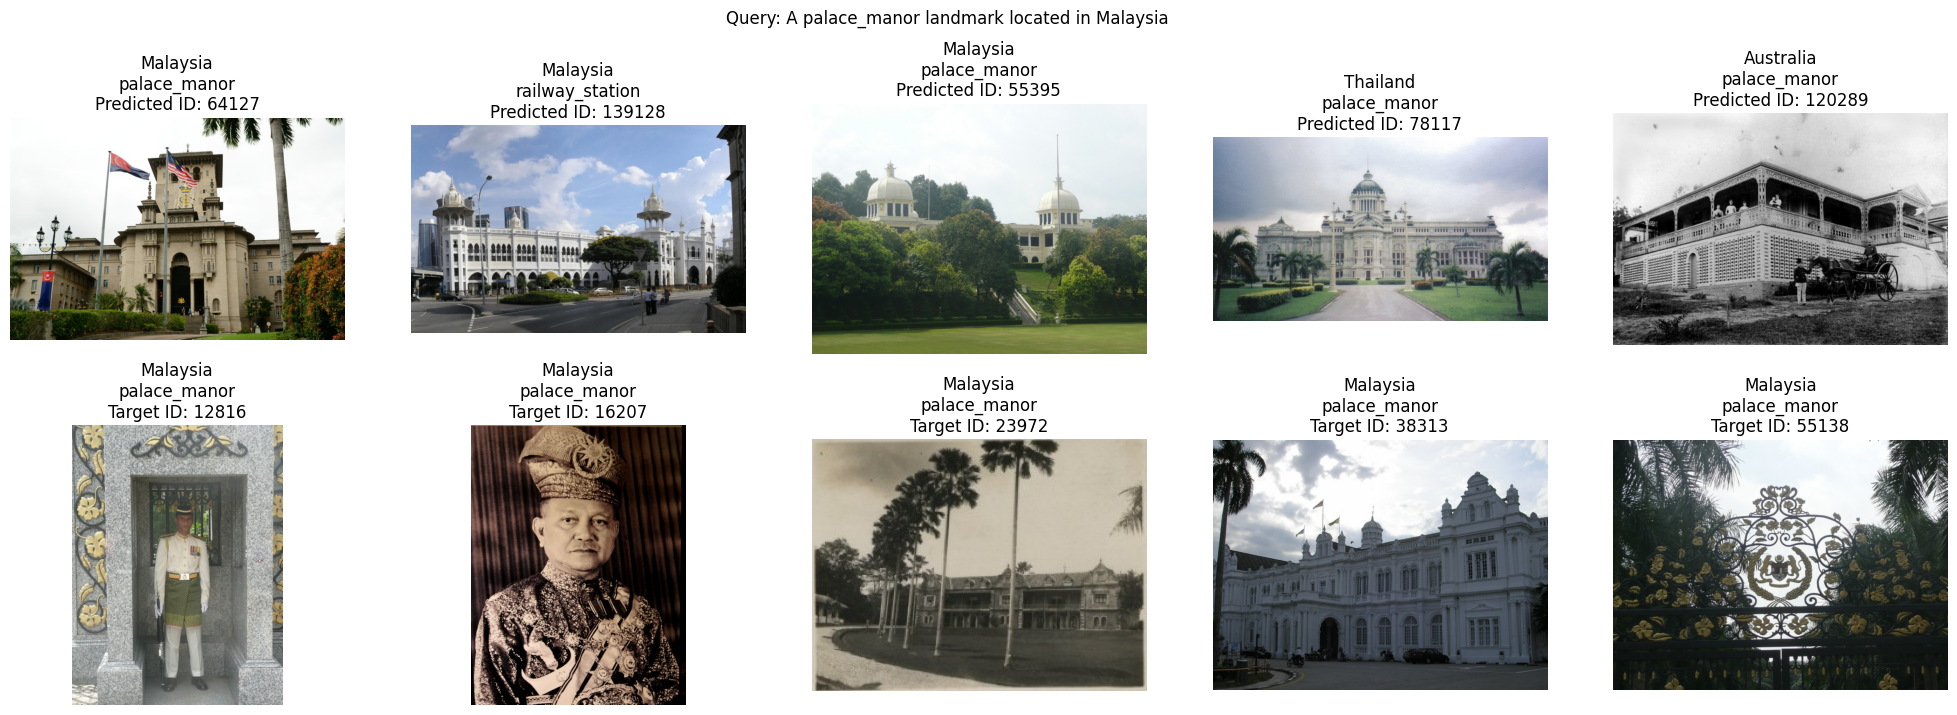

In [133]:
import matplotlib.pyplot as plt

top5_pred = [meta[p] for p in all_pred[0][:5]]
top5_gt = [meta[gt] for gt in all_gt[0][:5]]

fig, ax = plt.subplots(2, 5, figsize=(25, 8))
for i in range(5):
    ax[0, i].imshow(Image.open(os.path.join(base_img_path, f"{top5_pred[i]["id"]}.jpg")))
    ax[0, i].set_axis_off()
    ax[0, i].set_title(f"{top5_pred[i]["country"]}\n{top5_pred[i]["category"]}\nPredicted ID: {top5_pred[i]["row_idx"]}")
    
for i in range(5):
    ax[1, i].imshow(Image.open(os.path.join(base_img_path, f"{top5_gt[i]["id"]}.jpg")))
    ax[1, i].set_axis_off()
    ax[1, i].set_title(f"{top5_gt[i]["country"]}\n{top5_gt[i]["category"]}\nTarget ID: {top5_gt[i]["row_idx"]}")
fig.suptitle(f"Query: {queries[0]["query_text"]}")
plt.show()

In [32]:
from transformers import AutoModel
from src.index_clip import CLIP_MODEL_NAME
import torch

clip = AutoModel.from_pretrained(CLIP_MODEL_NAME).to("cuda")
clip = clip.eval()
clip = torch.compile(clip)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
clip_index, _ = read_index("../index/clip_index_gld_siglip_filtered")
clip_index.ntotal

203041

In [41]:
clip_all_gt = []
clip_all_pred = []

with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
    for q in tqdm(queries.to_dicts(), desc="evaluate"):
        q_tokenized = processor.tokenizer(
            q["query_text"],
            max_length=32,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        q_embed = clip.get_text_features(
            input_ids=q_tokenized["input_ids"].to("cuda"),
            attention_mask=q_tokenized["attention_mask"].to("cuda"),
        ).pooler_output
        q_embed = q_embed.cpu().float().numpy()

        sim, ind = index.search(q_embed, topk)
        ind = ind.squeeze().tolist()
        
        clip_all_gt.append(q["relevant_indices"])
        clip_all_pred.append(ind)

evaluate: 100%|██████████| 1209/1209 [00:43<00:00, 28.05it/s]


In [42]:
evaluate(clip_all_gt, clip_all_pred)

{'mAP@5': 0.14314033636614282,
 'mAP@10': 0.10571008441976183,
 'mAP@25': 0.0611812539410116,
 'mAP@50': 0.03646242392132696,
 'mAP@100': 0.020388539725441527}

In [31]:
import polars as pl

index_df = pl.read_csv("../../datasets/google-landmark/raw-csv/index_set_fixed.csv")
index_df

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url
str,i64,f64,f64,str,str
"""fdf40612109ad174""",32888,33.486266,-80.860517,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""5a6cc67c893daea6""",552,48.851075,2.285447,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""87b88acb68cdc1f1""",13626,40.758972,-73.979389,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""c4ac217ce087b251""",8699,42.097,-72.5633,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""05f269bf32be9d3e""",30838,50.681278,21.749444,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
…,…,…,…,…,…
"""ace1f52eea7620e9""",1463,53.001714,6.72987,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""f07d97acbc9cac79""",51420,52.377329,4.59569,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"
"""2a2bdc07e5144f71""",27922,17.242778,98.972222,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…"


In [33]:
index_df.sample(10).write_csv("./sample_df.csv")

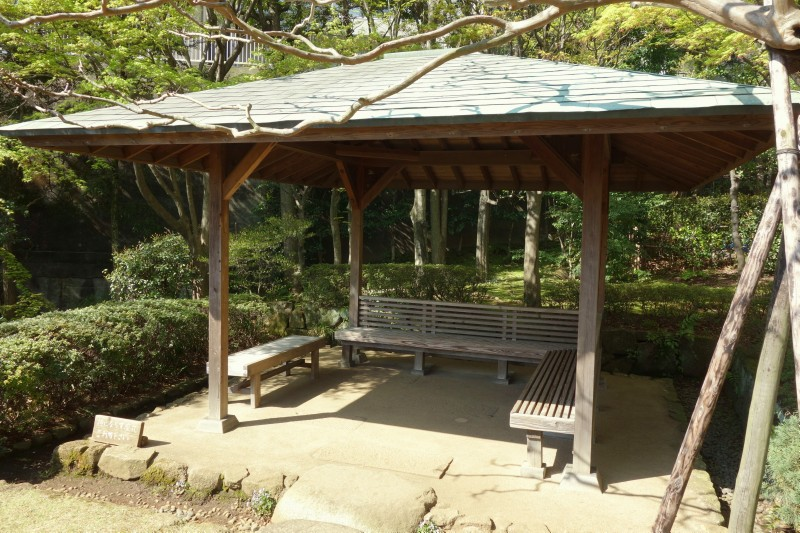

In [50]:
from PIL import Image
import os

Image.open(os.path.join("/mnt/yokoyamalab-nas/gldv2-full/index/","ecb567274c530189.jpg"))